# scVI embeddings analysis

UMAP of cell types colored by organ

In [2]:
# Minimal setup: imports and DATA_DIR discovery
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

_notebook_dir = os.path.dirname(os.path.abspath('scvi_embedding_analysis.ipynb'))
DATA_DIR = '../data/scvi'
parquet_files = sorted(glob.glob(os.path.join(DATA_DIR, '*_cell_type_embeds.parquet')))
if not parquet_files:
    raise FileNotFoundError(f'No *_cell_type_embeds.parquet files found in {DATA_DIR}.')

# Load and concatenate
dfs = []
for path in parquet_files:
    df = pd.read_parquet(path)
    df['source'] = os.path.basename(path).replace('_cell_type_embeds.parquet', '')
    dfs.append(df)
data = pd.concat(dfs, ignore_index=True)
scvi_cols = [c for c in data.columns if c.startswith('scvi_')]
if len(scvi_cols) == 0:
    raise ValueError('No scvi_ columns found in parquet files')
X = data[scvi_cols].values.astype(float)
labels = data['cell_ontology_class'].values
sources = data['source'].values
label_ids = LabelEncoder().fit_transform(labels)

/Users/irithkatiyar/Desktop/hst506/genai4bio-project/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


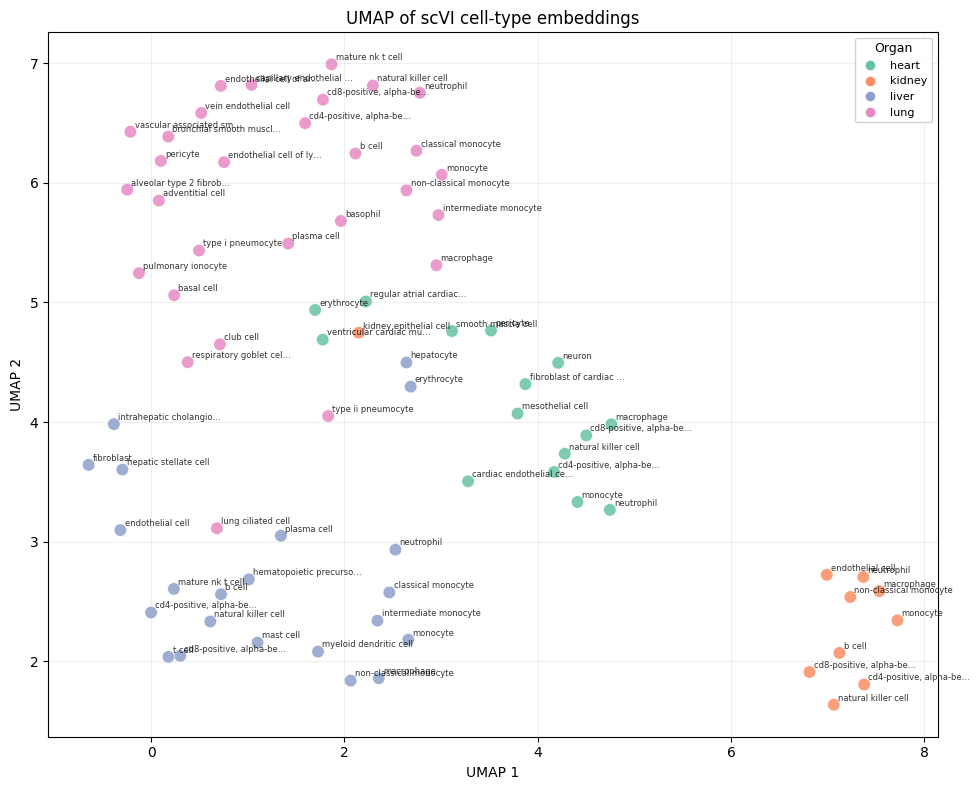

In [4]:
# UMAP plot: cell-type embeddings colored by organ (single panel)
ORGAN_COLORS = [
    '#66c2a5',  # teal
    '#fc8d62',  # orange
    '#8da0cb',  # blue
    '#e78ac3',  # pink
    '#a6d854',  # green
    '#ffd92f',  # yellow
    '#e5c494',  # tan
]

try:
    import umap
except Exception as e:
    raise ImportError('umap-learn is required for this notebook (pip install umap-learn)') from e

reducer = umap.UMAP(n_components=2, n_neighbors=min(15, max(2, len(X)-1)), min_dist=0.3, random_state=42)
X_umap = reducer.fit_transform(X)

# Derive organ names from source entries
organs = np.array([s.rsplit('_', 1)[0] for s in sources])
unique_organs = np.unique(organs)
organ_ids = LabelEncoder().fit_transform(organs)

if len(ORGAN_COLORS) < len(unique_organs):
    raise ValueError(f'ORGAN_COLORS has {len(ORGAN_COLORS)} entries but there are {len(unique_organs)} organs: {unique_organs.tolist()}')

point_colors = [ORGAN_COLORS[i] for i in organ_ids]

fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(X_umap[:, 0], X_umap[:, 1], c=point_colors, s=80, alpha=0.85, edgecolors='white', linewidths=0.4)
for x, y, lbl in zip(X_umap[:, 0], X_umap[:, 1], labels):
    short = lbl[:22] + ('…' if len(lbl) > 22 else '')
    ax.annotate(short, (x, y), fontsize=6, alpha=0.8, xytext=(3, 3), textcoords='offset points')

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=ORGAN_COLORS[i], markersize=8, label=organ)
           for i, organ in enumerate(unique_organs)]
ax.legend(handles=handles, title='Organ', fontsize=8, title_fontsize=9, loc='best', framealpha=0.9)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_title('UMAP of scVI cell-type embeddings')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()